# Training data chip creation
This notebook shows you how the Pipeline can be used to create 300x300 training chips for the toy model. These chips are matched with training COCO labels, and passed through the model at training time.

## Purpose of this notebook
This notebook is designed to get you familiar with the chip making workflow; 
- Load all COCO training image, label pairs
- For each training sample: 
    - Create a tiling Pipeline object
    - Query Pipeline by bounding box in lat, lon coords (upper left and lower right coordinates) and product ID (saves only matching PIDs)
    - Match images across LTM tile indices (1-4 tiles per query)
    - Merge, reproject, clip to training AOI, save to file
    - Copy over matching label
    - Visualize results
- Clean up memory

# Setup
Imports and repo clone.

In [1]:
import os
# Configure environment variable to suppress warning
os.environ['MALLOC_CONF'] = 'oversize_threshold:1,background_thread:true,metadata_thp:auto'

import json
import logging
from glob import glob
from contextlib import redirect_stdout, nullcontext
from functools import partial
from collections import Counter
from io import StringIO
import multiprocessing as mp
from multiprocessing import Pool, cpu_count, get_logger
import warnings

import rasterio
import xarray as xr
from rasterio.enums import Resampling
from rasterio.crs import CRS
from tqdm import tqdm
import subprocess
from pathlib import Path
import sys
import geopandas as gpd
import time
import rioxarray as rxr
import shutil
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from getpass import getuser

/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Get the repo root directory (parent of notebooks/)
repo_root = Path.cwd().parent

# Convert /panfs path to /explore path (JupyterHub quirk)
repo_root_str = str(repo_root).replace('/panfs/ccds02/nobackup', '/explore/nobackup')
repo_root = Path(repo_root_str)

# Verify we're in the right location
if not (repo_root / "model").exists():
    raise FileNotFoundError(
        "Cannot find lfm/model directory. "
        "Please ensure you're running this notebook from the lfm/notebooks/ directory."
    )

# Add the parent of the repo to sys.path for imports
sys.path.insert(0, str(repo_root.parent))

# Import required modules
from lfm.model.Pipeline import Pipeline
from lfm.model.chip_making.chip_utils import (
    extract_product_id, run_pipeline_for_sample, get_worker_logger, group_cubes_by_tile,
    merge_and_reproject_datasets, clip_and_combine_datasets, write_chip_to_tif
)
from lfm.model.chip_making.chip_constants import (
    PROJECT_DIR, GPKG_PATH, TILE_DB_PATH, ZOOM_LEVEL, CHIP_DIR, LABEL_DIR, COMMON_NODATA
)
from lfm.lfm.tasks.all_tasks.all_utils import prepare_output_dir
print("✓ Successfully imported LFM modules")

✓ Successfully imported LFM modules


<jemalloc>: Unsupported system page size


In [3]:
logger = get_worker_logger()

# User configuration
`DELETE_PREV_OUTPUTS`: whether to delete previous outputs; this is advised to be True, but is False by default.

`OUTPUT_DIR`: base output dir where you want the tiling outputs to go. 

<mark>Note: the notebook will create a subdirectory of this for your user; for Sandy, it creates one called "ajkerr1". If you want to do multiple experiments, make sure to change the directory path so that your outputs aren't overwritten!</mark>

`STATIC_BANDS`: exact band names of static bands to use in chip creation. If you would like to omit some of the bands, you can comment them out by hightlighting them and typing `#`.

In [4]:
DELETE_PREV_OUTPUTS = False  # Whether to delete previous chip creation runs

OUTPUT_DIR = PROJECT_DIR / "model_inputs/notebook_outputs" / str(getuser())
OUTPUT_DIR.mkdir(exist_ok=True)

STATIC_BANDS = [
    "LDRM_32_N_FLOAT.iau",
    "GlobeNoPolesDeltaCPR_v2-offsetto49d.iau",
    "GlobeNoPolesDeltaS1_v2.iau",
    "WAC_EMP_321NM.iau",
    "WAC_EMP_360NM.iau",
    "WAC_EMP_415NM.iau",
    "WAC_EMP_566NM.iau",
    "WAC_EMP_604NM.iau",
    "WAC_EMP_643NM.iau",
    "WAC_EMP_689NM.iau",
    "WAC_GLOBAL.iau",
    "WAC_TIO2.iau",
    "jggrx_1800f_me_dist_meters_20km_cog",
    "hpar_global128ppd_v1c_dateline_cut.iau3",
    "RA_SAM_70Sto70N.iau7",
    "diviner_tbol_snapshot_000E",
    "diviner_tbol_snapshot_015E",
    "diviner_tbol_snapshot_030E",
    "diviner_tbol_snapshot_045E",
    "diviner_tbol_snapshot_060E",
    "diviner_tbol_snapshot_075E",
    "diviner_tbol_snapshot_090E",
    "diviner_tbol_snapshot_105E",
    "diviner_tbol_snapshot_120E",
    "diviner_tbol_snapshot_135E",
    "diviner_tbol_snapshot_150E",
    "diviner_tbol_snapshot_165E",
    "diviner_tbol_snapshot_180E",
    "diviner_tbol_snapshot_195E",
    "diviner_tbol_snapshot_210E",
    "diviner_tbol_snapshot_225E",
    "diviner_tbol_snapshot_240E",
    "diviner_tbol_snapshot_255E",
    "diviner_tbol_snapshot_270E",
    "diviner_tbol_snapshot_285E",
    "diviner_tbol_snapshot_300E",
    "diviner_tbol_snapshot_315E",
    "diviner_tbol_snapshot_330E",
    "diviner_tbol_snapshot_345E",
    "TREG_ANOM_70Sto70N.iau7",
    "Lunar_Kaguya_MIMap_MineralDeconv_ClinopyroxenePercent_50N50S.iau2",
    "Lunar_Kaguya_MIMap_MineralDeconv_FeOWeightPercent_50N50S.iau2",
    "Lunar_Kaguya_MIMap_MineralDeconv_OlivinePercent_50N50S.iau2",
    "Lunar_Kaguya_MIMap_MineralDeconv_OpticalMaturityIndex_50N50S.iau2",
    "Lunar_Kaguya_MIMap_MineralDeconv_OrthopyroxenePercent_50N50S.iau2",
    "Lunar_Kaguya_MIMap_MineralDeconv_PlagioclaseGrainSizeMicrons_50N50S.iau2",
    "Lunar_Kaguya_MIMap_MineralDeconv_PlagioclasePercent_50N50S.iau2",
    "kaguya_mi_derived_30ppd_mpfe.iau",
    "kaguya_mi_derived_30ppd_npfe.iau",
    "kaguya_mi_derived_30ppd_smfe.iau",
    "Lunar_Kaguya_MIMap_Band1_MV1_414nm_65N65S_512ppd.iau2",
    "Lunar_Kaguya_MIMap_Band2_MV2_749nm_65N65S_512ppd.iau2",
    "Lunar_Kaguya_MIMap_Band3_MV3_901nm_65N65S_512ppd.iau2",
    "Lunar_Kaguya_MIMap_Band4_MV4_950nm_65N65S_512ppd.iau2",
    "Lunar_Kaguya_MIMap_Band5_MV5_1001nm_65N65S_512ppd.iau2",
    "Lunar_Kaguya_MIMap_Band7_MN2_1049nm_65N65S_512ppd.iau2",
    "Lunar_Kaguya_MIMap_Band8_MN3_1248nm_65N65S_512ppd.iau2",
    "Lunar_Kaguya_MIMap_Band9_MN4_1548nm_65N65S_512ppd.iau2",
    "lola_kaguya_60mpp_asp",
    "lola_kaguya_60mpp_cos",
    "lola_kaguya_60mpp_elv",
    "lola_kaguya_60mpp_sin",
    "lola_kaguya_60mpp_slp",
]

In [18]:
prep = prepare_output_dir(OUTPUT_DIR, DELETE_PREV_OUTPUTS)

✅ Using existing output_dir with current contents: /explore/nobackup/projects/lfm/model_inputs/notebook_outputs/ajkerr1


# Example run: single train sample

### 1. Load previous training geometries into GeoDataFrame
This is our set of AOIs we will use to filter our data with. 

In [6]:
train_gdf_path = GPKG_PATH
train_gdf = gpd.read_file(GPKG_PATH)
print(f"Loaded train gdf with {len(train_gdf)} entries.")

Loaded train gdf with 623 entries.


### 2. Run datacube pipeline for single sample
This creates some 512x512 .tifs in the Armstrong tiling scheme. See `tiling_example.ipynb` for examples on how the Pipeline works.

In [7]:
entry = train_gdf.iloc[0].to_dict()
entry

{'location': 'M1096558039CE_r7650_c750_input_wac_static_chip.tif',
 'geometry': <POLYGON ((-11.389 -5.164, -10.396 -5.168, -10.4 -6.158, -11.395 -6.152, -11...>}

In [8]:
train_fn = entry['location']
product_id = extract_product_id(train_fn)
print(f"Product ID: {product_id}")

# Save to datacube subdirectory
train_fn_no_ext = train_fn.split("_input")[0]
datacube_base_dir = OUTPUT_DIR / "datacubes"
datacube_dir = datacube_base_dir / train_fn_no_ext
datacube_dir.mkdir(exist_ok=True, parents=True)

Product ID: M1096558039CE


In [9]:
print("Running pipeline...")

pipeline_start = time.time()

cube_files, pipeline_status = run_pipeline_for_sample(
    train_fn=train_fn,
    product_id=product_id,
    geom_bounds=entry['geometry'].bounds,  # (ulLon, lrLat, lrLon, ulLat)
    datacube_dir=datacube_dir,
    TILE_DB_PATH=TILE_DB_PATH,
    logger=logger,
    zoom_level=ZOOM_LEVEL
)
pipeline_end = time.time() - pipeline_start

if not cube_files:
    print("WARNING: no datacubes created.")
if pipeline_status != "success":
    print(f"WARNING: Pipeline status: {pipeline_status}")
else:
    print(f"Pipeline successfully ran for train sample. Number of files created: {len(cube_files)}")
    print(f"Pipeline ran in {pipeline_end} seconds.")

Running pipeline...


Created pipeline instance for PID: M1096558039CE
Found LTM zone intersection: 22S
Processing tile (0, 4) / zone 22S / zoom 5
Total WAC product IDs: 1
Total Static product IDs: 63
Processing tile (1, 4) / zone 22S / zoom 5
Total WAC product IDs: 1
Total Static product IDs: 63


Pipeline successfully ran for train sample. Number of files created: 4
Pipeline ran in 9.032532691955566 seconds.


### 3. Match WAC/STATIC files across tile indices
This allows us to merge them into a single chip later. 

In [10]:
# Step a: group them by LTM tile
cubes_by_tile, _ = group_cubes_by_tile([str(f) for f in cube_files], logger)

# Step b: match WAC/STATIC across tiles
wac_files = []
static_files = []

for tile_id, elems in cubes_by_tile.items():
    wac_match = [f for f in elems['wac'] if f"ProdId-{product_id}" in f]
    static_match = [f for f in elems['static']]
    wac_files.append(wac_match[0])
    static_files.append(static_match[0])

print(cubes_by_tile)

{'0-4': {'wac': ['/explore/nobackup/projects/lfm/model_inputs/notebook_outputs/ajkerr1/datacubes/M1096558039CE_r7650_c750/Cube-LTM22S_Zoom-5_Tile-0-4_ProdId-M1096558039CE.tif'], 'static': ['/explore/nobackup/projects/lfm/model_inputs/notebook_outputs/ajkerr1/datacubes/M1096558039CE_r7650_c750/StaticCube-LTM22S_Zoom-5_Tile-0-4.tif']}, '1-4': {'wac': ['/explore/nobackup/projects/lfm/model_inputs/notebook_outputs/ajkerr1/datacubes/M1096558039CE_r7650_c750/Cube-LTM22S_Zoom-5_Tile-1-4_ProdId-M1096558039CE.tif'], 'static': ['/explore/nobackup/projects/lfm/model_inputs/notebook_outputs/ajkerr1/datacubes/M1096558039CE_r7650_c750/StaticCube-LTM22S_Zoom-5_Tile-1-4.tif']}}


### 4. Load reference train chip
This allows us to clip to the proper extent of our labels.

In [11]:
train_path = CHIP_DIR / train_fn
train_ds = rxr.open_rasterio(train_path)

target_crs = train_ds.rio.crs
target_transform = train_ds.rio.transform()
target_height = train_ds.shape[-2]
target_width = train_ds.shape[-1]
train_bbox = train_ds.rio.bounds()
train_shape = train_ds.shape

### 5. Merge, reproject, and clip WAC, STATIC datacubes
This gets them aligned with the original training sample and labels. 

In [12]:
merge_reproj_result = merge_and_reproject_datasets(
    wac_files=wac_files,
    static_files=static_files,
    target_crs=target_crs,
    target_transform=target_transform,
    target_height=target_height,
    target_width=target_width,
    static_band_list=STATIC_BANDS,
    logger=logger
)
merged_wac, merged_static, wac_band_names, static_band_names, _ = merge_reproj_result

In [13]:
combined, all_band_names, combine_status = clip_and_combine_datasets(
    merged_wac=merged_wac,
    merged_static=merged_static,
    wac_band_names=wac_band_names,
    static_band_names=static_band_names,
    train_bbox=train_bbox,
    train_shape=train_shape,
    logger=logger
)

### 6. Save chip to file
We will now save our in-memory chip to a file in the output directory.

In [14]:
chip_output_dir = OUTPUT_DIR / "chips"
chip_output_dir.mkdir(exist_ok=True, parents=True)
chip_output_filename = chip_output_dir / f"{train_fn_no_ext}_wac_static_chip.tif"

COMMON_NODATA = -3.40282265508890445e+38
write_status = write_chip_to_tif(
    combined=combined,
    output_filename=chip_output_filename,
    all_band_names=all_band_names,
    logger=logger,
    nodata_value=COMMON_NODATA
)

### 7. Copy over matching label
This is so that we have matching image/label pairs for training.

In [15]:
label_path = next(LABEL_DIR.glob(f"*{product_id}*.npz"))
print(f"Found matching label: {label_path}")

label_output_dir = OUTPUT_DIR / "labels"
label_output_dir.mkdir(exist_ok=True, parents=True)
basename = train_fn.split("_input")[0]
label_basename = f"{basename}_label.npz"

shutil.copy(label_path, label_output_dir / label_basename)
label_new_path = next(label_output_dir.glob(label_basename))
if label_new_path: 
    print(f"Label copied successfully!")

Found matching label: /explore/nobackup/projects/lfm/model_inputs/300_300_inputs/7_band_vis_uv/sem_seg/labels/M1096558039CE_r7650_c750_label.npz
Label copied successfully!


### 8. Visualize our new output vs the old output
Side-by side comparison of our chip versus the original training sample we used from the COCO dataset.

**Row 1**: 

- **Column 1**: New chip created in this notebook
- **Column 2**: Old chip from COCO

**Row 2**:

- **Column 1**: New label created in this notebook
- **Column 2**: Old label from COCO

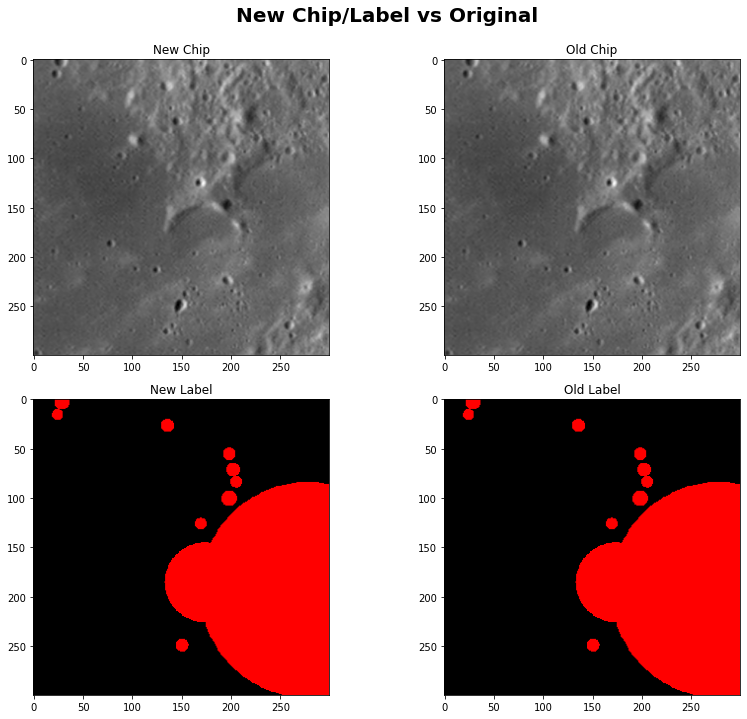

In [16]:
# Load chips, labels
chip_datasets = [rxr.open_rasterio(f).values for f in [chip_output_filename, train_path]]
chip_single_bands = [chip.transpose(1, 2, 0)[:, :, 0] for chip in chip_datasets]
label_datasets = [np.load(f, allow_pickle=True)['data'] for f in [label_new_path, label_path]]

# Create colormap, matplotlib grid plot
cmap_black_red = ListedColormap(["black", "red"])
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot chips in first row
axes[0, 0].imshow(chip_single_bands[0], cmap='gray')
axes[0, 0].set_title("New Chip")
axes[0, 1].imshow(chip_single_bands[1], cmap='gray')
axes[0, 1].set_title("Old Chip")

# Plot labels in second row
axes[1, 0].imshow(label_datasets[0], cmap=cmap_black_red)
axes[1, 0].set_title("New Label")
axes[1, 1].imshow(label_datasets[1], cmap=cmap_black_red)
axes[1, 1].set_title("Old Label")

# Finalize plot with title, tight layout
fig.suptitle("New Chip/Label vs Original", fontsize=20, fontweight="bold", y=0.995)
plt.tight_layout()

## 9. Clean up
Clean our memory by closing datasets.

In [17]:
combined.close()
merged_wac.close()
merged_static.close()
train_ds.close()